# HAM10000 Skin Lesion Binary Classification (Scenario 1)

> **Research Framework**: Fair comparison of VGG16, DenseNet121, EfficientNetB0
> using consistent pipeline and two-phase transfer learning.
>
> **Scenario**: Binary — Cancer vs Non-Cancer

## Import Library

In [1]:
import os, glob, shutil, math, random, time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from IPython.display import display

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score, accuracy_score,
    precision_score, recall_score,
    cohen_kappa_score, roc_auc_score,
)

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, CSVLogger, LearningRateScheduler
)
from tensorflow.keras.applications import EfficientNetB0, DenseNet121, VGG16
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

## Konfigurasi & Konstanta

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ===== Mixed Precision Training =====
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# ===== Data Paths =====
BASE_DIR = r'C:\Users\ASUS\OneDrive\Desktop\SkinNova A Novel Deep Learning Framework for Skin Cancer Detection and Explainable Diagnosis\Dataset'
OUTPUT_DIR = r'C:\Users\ASUS\OneDrive\Desktop\SkinNova A Novel Deep Learning Framework for Skin Cancer Detection and Explainable Diagnosis\Output'
metadata_path = os.path.join(BASE_DIR, "HAM10000_metadata.csv")
image_dirs = [
    os.path.join(BASE_DIR, "HAM10000_images_part_1"),
    os.path.join(BASE_DIR, "HAM10000_images_part_2"),
]
AUGMENTED_DIR = os.path.join(OUTPUT_DIR, 'augmented_train')
PROCESSED_DIR = os.path.join(OUTPUT_DIR, 'processed')

# ===== Hyperparameters =====
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 1
EPOCHS_BASE = 60
EPOCHS_FT   = 100

LR_BASE     = 1e-3
LR_MAX_FT   = 5e-5         # FT Learning rate standard
L2_REG      = 1e-3
RE_PROB     = 0.0          # No random erasing

# [FIX] OFFLINE AUGMENTATION / OVERSAMPLING AKTIF
OVERSAMPLE_RATIO = 1.0     # Target 50:50 balance

# [FIX] DROPOUT
DROPOUT_VGG = 0.40
DROPOUT_DN  = 0.50
DROPOUT_EFF = 0.50

# ===== Label Mapping =====
NON_CANCER_CLASSES = ["bkl", "df", "nv", "vasc"]
CANCER_CLASSES     = ["bcc", "mel", "akiec"]
CLASS_NAMES  = ['0', '1']
TARGET_NAMES = ["Normal", "Cancer"]

print(f"Fixed params: IMG={IMG_SIZE}, BS={BATCH_SIZE}, LR_BASE={LR_BASE}, LR_FT={LR_MAX_FT}")
print(f"Oversampling ratio: {OVERSAMPLE_RATIO} (OFFLINE AUGMENTATION AKTIF)")
print(f"Online Augmentation: DISABLED")
print(f"Loss Function: Binary Crossentropy (Karena data sudah 50:50)")


Fixed params: IMG=(224, 224), BS=32, LR_BASE=0.001, LR_FT=5e-05
Oversampling ratio: 1.0 (OFFLINE AUGMENTATION AKTIF)
Online Augmentation: DISABLED
Loss Function: Binary Crossentropy (Karena data sudah 50:50)


## Data Loading & Binary Mapping

In [5]:
df_meta = pd.read_csv(metadata_path)

path_map = {}
for d in image_dirs:
    for f in glob.glob(os.path.join(d, '*.jpg')):
        path_map[os.path.splitext(os.path.basename(f))[0]] = f

df_meta['path'] = df_meta['image_id'].map(path_map)
df_meta = df_meta.dropna(subset=['path']).reset_index(drop=True)

def map_to_binary(dx_label):
    if dx_label in NON_CANCER_CLASSES: return '0'
    elif dx_label in CANCER_CLASSES: return '1'
    return None

df_meta['label'] = df_meta['dx'].apply(map_to_binary)

print("Total images:", len(df_meta))
print("\n--- Distribusi Kelas Asli (dx) ---")
print(df_meta['dx'].value_counts())
print("\n--- Distribusi Kelas Baru (Binary) ---")
print(df_meta['label'].value_counts())
print("\n--- Jumlah Unique lesion_id ---")
print(f"Total: {df_meta['lesion_id'].nunique()}")

Total images: 10015

--- Distribusi Kelas Asli (dx) ---
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

--- Distribusi Kelas Baru (Binary) ---
label
0    8061
1    1954
Name: count, dtype: int64

--- Jumlah Unique lesion_id ---
Total: 7470


## Image Preprocessing

In [6]:
def blackhat_filter(img_bgr, kernel_size=17, thresh=10):
    gray   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask  = cv2.threshold(blackhat, thresh, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(img_bgr, mask, 1, cv2.INPAINT_TELEA)

def apply_clahe(img_bgr, clip_limit=2.0, tile_size=(8, 8)):
    """CLAHE — Contrast Limited Adaptive Histogram Equalization.
    Meningkatkan kontras lokal untuk mempertegas fitur diagnostik lesi kulit.
    Ref: [Codella et al., 2018] ISIC Challenge, [Ratul et al., 2020]
    """
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

if os.path.exists(PROCESSED_DIR):
    shutil.rmtree(PROCESSED_DIR)
for c in CLASS_NAMES:
    os.makedirs(os.path.join(PROCESSED_DIR, c), exist_ok=True)

processed_rows = []
for _, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc='Preprocessing (Blackhat + CLAHE)'):
    img = cv2.imread(row['path'])
    if img is None: continue
    img = blackhat_filter(img)      # Step 1: Hair removal
    img = apply_clahe(img)          # Step 2: Enhance local contrast [NEW]
    img = cv2.resize(img, IMG_SIZE) # Step 3: Resize to 224x224
    out_path = os.path.join(PROCESSED_DIR, row['label'], row['image_id'] + '.jpg')
    cv2.imwrite(out_path, img)
    processed_rows.append({'image_id': row['image_id'], 'path': out_path, 'label': row['label'], 'lesion_id': row['lesion_id']})

df_proc = pd.DataFrame(processed_rows)
print(f"Preprocessing selesai: {len(df_proc)} gambar (Blackhat + CLAHE + Resize)")


Preprocessing (Blackhat + CLAHE): 100%|██████████| 10015/10015 [07:19<00:00, 22.79it/s]

Preprocessing selesai: 10015 gambar (Blackhat + CLAHE + Resize)


## Data Splitting (80/10/10) — GroupShuffleSplit by `lesion_id`

In [7]:
gss_1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, temp_idx = next(gss_1.split(df_proc, df_proc['label'], groups=df_proc['lesion_id']))
train_df = df_proc.iloc[train_idx].reset_index(drop=True)
temp_df  = df_proc.iloc[temp_idx].reset_index(drop=True)

gss_2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(gss_2.split(temp_df, temp_df['label'], groups=temp_df['lesion_id']))
val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

train_lesions = set(train_df['lesion_id'].unique())
val_lesions   = set(val_df['lesion_id'].unique())
test_lesions  = set(test_df['lesion_id'].unique())

assert len(train_lesions & val_lesions) == 0, "LEAKAGE: train & val share lesion_id!"
assert len(train_lesions & test_lesions) == 0, "LEAKAGE: train & test share lesion_id!"
assert len(val_lesions & test_lesions) == 0, "LEAKAGE: val & test share lesion_id!"

print(f"[SPLIT SELESAI] Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"[LEAKAGE CHECK] Train lesions: {len(train_lesions)} | Val: {len(val_lesions)} | Test: {len(test_lesions)}")
print("[OK] Tidak ada overlap lesion_id antar split.")

[SPLIT SELESAI] Train: 7991 | Val: 1025 | Test: 999
[LEAKAGE CHECK] Train lesions: 5976 | Val: 747 | Test: 747
[OK] Tidak ada overlap lesion_id antar split.


## Oversampling & Augmentasi Cancer

Target sampel kelas Cancer (khusus Train Set): 6430 (rasio=1.0)
Kelas 1: 1561 gambar -> generate 4869 augmentasi offline
Found 1561 validated image filenames.


Augmenting Class 1: 100%|██████████| 4869/4869 [01:00<00:00, 80.98it/s]



Distribusi Akhir -> Train Balanced: 12860 | Val Asli: 1025 | Test Asli: 999


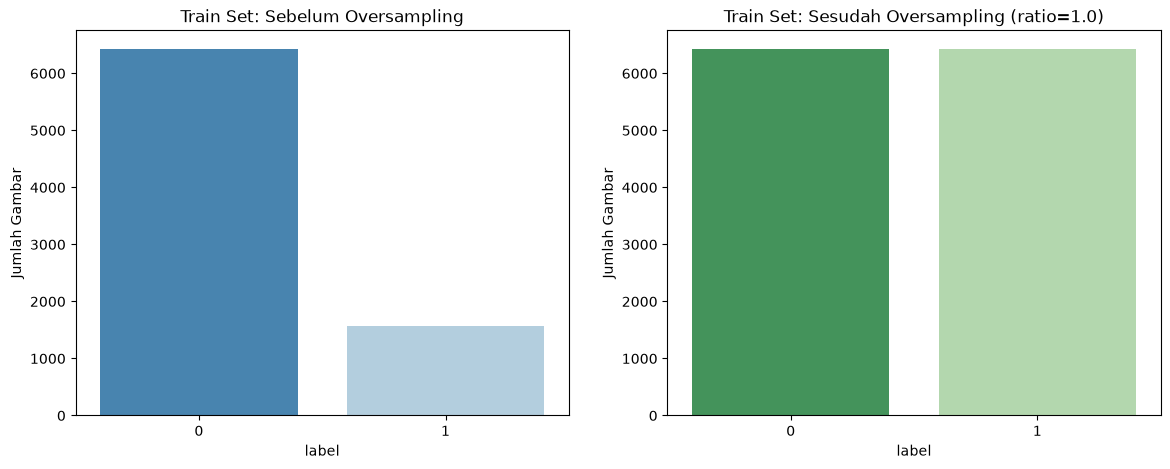

In [8]:
# ===== OFFLINE AUGMENTATION (OVERSAMPLING) =====
# Karena OVERSAMPLE_RATIO = 1.0, data akan diseimbangkan 50:50
if os.path.exists(AUGMENTED_DIR):
    shutil.rmtree(AUGMENTED_DIR)
for cls in CLASS_NAMES:
    os.makedirs(os.path.join(AUGMENTED_DIR, cls), exist_ok=True)

offline_datagen = ImageDataGenerator(
    rotation_range=90,          # Kembali ke 90 untuk variasi maksimal
    width_shift_range=0.1,      # Kembali ke 0.1
    height_shift_range=0.1,     # Kembali ke 0.1
    zoom_range=0.15,            # Kembali ke 0.15
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect'
)

train_counts = train_df['label'].value_counts()
max_samples = int(train_counts.max() * OVERSAMPLE_RATIO)

aug_rows = []
for cls in CLASS_NAMES:
    n_samples = train_counts.get(cls, 0)
    target = max_samples
    if n_samples >= target:
        continue
    
    needed = target - n_samples
    cls_df = train_df[train_df['label'] == cls]
    print(f"Target sampel kelas {TARGET_NAMES[int(cls)]} (khusus Train Set): {target} (rasio={OVERSAMPLE_RATIO})")
    print(f"Kelas {cls}: {n_samples} gambar -> generate {needed} augmentasi offline")
    
    gen = offline_datagen.flow_from_dataframe(
        cls_df, x_col='path', y_col=None, target_size=IMG_SIZE,
        batch_size=1, class_mode=None, shuffle=True
    )
    
    with tqdm(total=needed, desc=f"Augmenting Class {cls}") as pbar:
        for idx in range(needed):
            batch = next(gen)
            out_path = os.path.join(AUGMENTED_DIR, cls, f'{cls}_aug_{idx}.jpg')
            
            array_to_img(batch[0]).save(out_path)
            
            aug_rows.append({'path': out_path, 'label': cls})
            pbar.update(1)

df_aug = pd.DataFrame(aug_rows)
train_df_balanced = pd.concat([train_df[['path','label']], df_aug], ignore_index=True)
train_df_balanced = train_df_balanced.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nDistribusi Akhir -> Train Balanced: {len(train_df_balanced)} | Val Asli: {len(val_df)} | Test Asli: {len(test_df)}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts_before = train_df['label'].value_counts().sort_index()
counts_after  = train_df_balanced['label'].value_counts().sort_index()

sns.barplot(x=counts_before.index, y=counts_before.values, ax=axes[0], hue=counts_before.index, palette='Blues_r', legend=False)
axes[0].set_title('Train Set: Sebelum Oversampling'); axes[0].set_ylabel('Jumlah Gambar')
sns.barplot(x=counts_after.index, y=counts_after.values, ax=axes[1], hue=counts_after.index, palette='Greens_r', legend=False)
axes[1].set_title(f'Train Set: Sesudah Oversampling (ratio={OVERSAMPLE_RATIO})'); axes[1].set_ylabel('Jumlah Gambar')
plt.show()

## Helper Functions

In [9]:
def remote_random_erasing(img_tensor, p=RE_PROB, sl=0.02, sh=0.2, r1=0.3):
    if np.random.rand() > p: return img_tensor
    h, w, c = img_tensor.shape
    area = h * w
    for _ in range(10):
        target_area = np.random.uniform(sl, sh) * area
        aspect_ratio = np.random.uniform(r1, 1/r1)
        cut_h = int(np.round(np.sqrt(target_area * aspect_ratio)))
        cut_w = int(np.round(np.sqrt(target_area / aspect_ratio)))
        if cut_w < w and cut_h < h:
            x1 = np.random.randint(0, h - cut_h)
            y1 = np.random.randint(0, w - cut_w)
            img_tensor[x1:x1+cut_h, y1:y1+cut_w, :] = np.random.uniform(0, 255, (cut_h, cut_w, c))
            break
    return img_tensor

In [10]:
def build_generators(preprocess_fn):
    # Pipeline minimal: hanya model-specific preprocessing
    # Tidak ada online augmentation — offline aug (cell 12) sudah cukup [Perez & Wang, 2017]
    # Tidak ada Random Erasing — merusak fitur diagnostik [Zhong et al., 2020]
    train_gen = ImageDataGenerator(preprocessing_function=preprocess_fn)
    val_test_gen = ImageDataGenerator(preprocessing_function=preprocess_fn)
    
    train = train_gen.flow_from_dataframe(train_df_balanced, x_col='path', y_col='label',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary',
        classes=CLASS_NAMES, shuffle=True, seed=SEED)
    val = val_test_gen.flow_from_dataframe(val_df, x_col='path', y_col='label',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary',
        classes=CLASS_NAMES, shuffle=False)
    test = val_test_gen.flow_from_dataframe(test_df, x_col='path', y_col='label',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary',
        classes=CLASS_NAMES, shuffle=False)
    return train, val, test


In [11]:
# [FIX] MENGGUNAKAN BINARY CROSSENTROPY
# Karena data sudah 50:50 melalui oversampling, kita HARUS menggunakan BCE (Focal Loss akan menyebabkan loss bocor ke 0 untuk kelas minoritas yang diulang).
# Tambahkan label_smoothing=0.05 untuk mencegah overconfidence (terutama karena tidak ada online aug).
def get_loss_fn():
    return tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05)


In [12]:
def build_model(base_builder, dropout_rate, input_shape=IMG_SIZE + (3,)):
    # TIDAK ADA ONLINE AUGMENTATION (Sesuai kesepakatan)
    base = base_builder(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = False
    
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate * 0.5)(x)
    
    # dtype='float32' wajib untuk stabilitas numerik di mixed precision
    outputs = layers.Dense(NUM_CLASSES, activation='sigmoid', 
                          kernel_regularizer=regularizers.l2(L2_REG),
                          dtype='float32')(x)
    
    return Model(base.input, outputs), base


In [13]:
def get_base_callbacks(model_name, lr_max=LR_BASE, epochs_total=EPOCHS_BASE):
    def cosine_lr_schedule(epoch):
        lr_min = 1e-6
        return lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * epoch / epochs_total))
        
    ckpt = os.path.join(OUTPUT_DIR, f"{model_name}_best.keras")
    return [
        LearningRateScheduler(cosine_lr_schedule, verbose=0),
        EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=ckpt, monitor='val_auc', mode='max', save_best_only=True, verbose=0),
        CSVLogger(os.path.join(OUTPUT_DIR, f"{model_name}_log.csv"), append=True),
    ]

def get_ft_callbacks(model_name, lr_max=LR_MAX_FT, epochs_total=EPOCHS_FT):
    def cosine_lr_ft_schedule(epoch):
        lr_min = 1e-7
        return lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * epoch / epochs_total))
        
    ckpt = os.path.join(OUTPUT_DIR, f"{model_name}_best.keras")
    return [
        LearningRateScheduler(cosine_lr_ft_schedule, verbose=0),
        EarlyStopping(monitor='val_auc', mode='max', patience=12, restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=ckpt, monitor='val_auc', mode='max', save_best_only=True, verbose=0),
        CSVLogger(os.path.join(OUTPUT_DIR, f"{model_name}_log.csv"), append=True),
    ]


In [14]:
def evaluate_model(model, test_gen):
    test_gen.reset()
    y_score = model.predict(test_gen, verbose=0).flatten()
    y_pred  = (y_score > 0.5).astype(int) 
    y_true  = test_gen.classes

    cm = confusion_matrix(y_true, y_pred)
    
    TN, FP, FN, TP = cm.ravel()
    far = FP / (FP + TN + 1e-10)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_val = auc(fpr, tpr)

    return {
        'accuracy'   : accuracy_score(y_true, y_pred),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
        'kappa'      : cohen_kappa_score(y_true, y_pred),
        'far_macro'  : far,
        'auc'        : auc_val,
        'report'     : classification_report(y_true, y_pred, target_names=TARGET_NAMES, output_dict=True, zero_division=0),
        '_y_true': y_true, '_y_pred': y_pred, '_y_score': y_score, '_cm': cm, '_fpr': fpr, '_tpr': tpr
    }

def print_metrics(res, label):
    print(f"  Accuracy : {res['accuracy']:.4f} | F1: {res['f1_weighted']:.4f} "
          f"| AUC: {res['auc']:.4f} | Kappa: {res['kappa']:.4f} | FAR: {res['far_macro']:.4f}")

def plot_cm(cm, title, ax):
    cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, ax=ax)
    for t in ax.texts: t.set_text(t.get_text() + " %")
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

RESULTS       = {}
TRAINING_TIME = {}
HISTORIES     = {}
MODELS        = {}
TEST_GENS     = {}


## Training — VGG16

### VGG16 Base

In [15]:
K.clear_session()
train_vgg, val_vgg, test_vgg = build_generators(vgg_preprocess)
model_vgg, base_vgg = build_model(VGG16, DROPOUT_VGG)
model_vgg.compile(
    optimizer=Adam(LR_BASE),
    loss=get_loss_fn(),  
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

t0 = time.time()
hist_vgg_base = model_vgg.fit(
    train_vgg, validation_data=val_vgg,
    epochs=EPOCHS_BASE, 
    callbacks=get_base_callbacks("VGG16_Base"),
    class_weight={0: 1.0, 1: 1.4},
    verbose=1,
)
TRAINING_TIME["VGG16_Base"] = time.time() - t0

res = evaluate_model(model_vgg, test_vgg)
RESULTS["VGG16_Base"]  = res
HISTORIES["VGG16_Base"] = hist_vgg_base
print_metrics(res, "VGG16 Base")

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plot_cm(res['_cm'], 'VGG16 Base - Confusion Matrix (%)', ax)
plt.tight_layout(); 
plt.show()


Found 12860 validated image filenames belonging to 2 classes.
Found 1025 validated image filenames belonging to 2 classes.
Found 999 validated image filenames belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step
Epoch 1/60
 44/402 ━━━━━━━━━━━━━━━━━━━━ 19:54 3s/step - accuracy: 0.7450 - auc: 0.8388 - loss: 1.0274

KeyboardInterrupt: 

### VGG16 Fine-tune

In [ ]:
# Fine-tune: unfreeze block5 only
base_vgg.trainable = True
for layer in base_vgg.layers:
    layer.trainable = layer.name.startswith('block5')
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False  # Freeze BN — preserve pretrained statistics
        
model_vgg.compile(
    optimizer=Adam(LR_MAX_FT),
    loss=get_loss_fn(),   # [FIX] Ganti Focal Loss menjadi BCE
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

t0 = time.time()
hist_vgg_ft = model_vgg.fit(
    train_vgg, validation_data=val_vgg,
    epochs=EPOCHS_FT,
    callbacks=get_ft_callbacks("VGG16_FineTuned"),
    class_weight={0: 1.0, 1: 1.4}, 
    verbose=1,
)
TRAINING_TIME["VGG16_FineTuned"] = time.time() - t0
MODELS["VGG16_FineTuned"] = model_vgg
TEST_GENS["VGG16_FineTuned"] = test_vgg
 
res = evaluate_model(model_vgg, test_vgg)
RESULTS["VGG16_FineTuned"]  = res
HISTORIES["VGG16_FineTuned"] = hist_vgg_ft
print_metrics(res, "VGG16 FineTuned")

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plot_cm(res['_cm'], 'VGG16 FineTuned - Confusion Matrix (%)', ax)
plt.tight_layout();
plt.show()

## Training — DenseNet121

### DenseNet121 Base

In [ ]:
K.clear_session()
train_dn, val_dn, test_dn = build_generators(dense_preprocess)
model_dn, base_dn = build_model(DenseNet121, DROPOUT_DN)

model_dn.compile(
    optimizer=Adam(LR_BASE),
    loss=get_loss_fn(), # Menggunakan BCE
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Tambahkan bias 25% lebih berat untuk kelas Cancer (1)
t0 = time.time()
hist_dn_base = model_dn.fit(
    train_dn, validation_data=val_dn,
    epochs=EPOCHS_BASE,
    callbacks=get_base_callbacks("DenseNet121_Base"),
    class_weight={0: 1.0, 1: 1.0},
    verbose=1,
)
TRAINING_TIME["DenseNet121_Base"] = time.time() - t0

res = evaluate_model(model_dn, test_dn)
RESULTS["DenseNet121_Base"]  = res
HISTORIES["DenseNet121_Base"] = hist_dn_base
print_metrics(res, "DenseNet121 Base")

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plot_cm(res['_cm'], 'DenseNet121 Base - Confusion Matrix (%)', ax)
plt.tight_layout()
plt.show()

### DenseNet121 Fine-tune

In [ ]:
base_dn.trainable = True
for layer in base_dn.layers:
    if 'conv5_block' in layer.name:
        block_num = int(layer.name.split('_')[1].replace('block', ''))
        if block_num >= 10:                 # [FIX] Kunci kembali, hanya buka block 10 ke atas
            layer.trainable = True
        else:
            layer.trainable = False
    elif layer.name.startswith('conv5'): 
        layer.trainable = True
    else:
        layer.trainable = False
        
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False 

model_dn.compile(
    optimizer=Adam(LR_MAX_FT),
    loss=get_loss_fn(), # Menggunakan BCE
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Tambahkan bias 25% lebih berat untuk kelas Cancer (1)
t0 = time.time()
hist_dn_ft = model_dn.fit(
    train_dn, validation_data=val_dn,
    epochs=EPOCHS_FT,
    callbacks=get_ft_callbacks("DenseNet121_FineTuned"),
    class_weight={0: 1.0, 1: 1.0},
    verbose=1,
)
TRAINING_TIME["DenseNet121_FineTuned"] = time.time() - t0
MODELS["DenseNet121_FineTuned"] = model_dn
TEST_GENS["DenseNet121_FineTuned"] = test_dn

res = evaluate_model(model_dn, test_dn)
RESULTS["DenseNet121_FineTuned"]  = res
HISTORIES["DenseNet121_FineTuned"] = hist_dn_ft
print_metrics(res, "DenseNet121 FineTuned")

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plot_cm(res['_cm'], 'DenseNet121 FineTuned - Confusion Matrix (%)', ax)
plt.tight_layout()
plt.show()

## Training — EfficientNetB0

### EfficientNetB0 Base

In [ ]:
K.clear_session()
train_eff, val_eff, test_eff = build_generators(eff_preprocess)
model_eff, base_eff = build_model(EfficientNetB0, DROPOUT_EFF)
model_eff.compile(
    optimizer=Adam(LR_BASE),   
    loss=get_loss_fn(), # [FIX] Wajib BCE karena data sudah oversample 50:50
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Tambahkan bias 1.75 untuk kelas Cancer
t0 = time.time()
hist_eff_base = model_eff.fit(
    train_eff, validation_data=val_eff,
    epochs=EPOCHS_BASE,
    callbacks=get_base_callbacks("EfficientNetB0_Base"),
    class_weight={0: 1.0, 1: 1.05},  
    verbose=1,
)
TRAINING_TIME["EfficientNetB0_Base"] = time.time() - t0

res = evaluate_model(model_eff, test_eff)
RESULTS["EfficientNetB0_Base"]   = res
HISTORIES["EfficientNetB0_Base"] = hist_eff_base
print_metrics(res, "EfficientNetB0 Base")

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plot_cm(res['_cm'], 'EfficientNetB0 Base - Confusion Matrix (%)', ax)
plt.tight_layout(); 
plt.show()

### EfficientNetB0 Fine-tune

In [ ]:
# Fine-tune: unfreeze block5 + block6 + block7 + top only
base_eff.trainable = True
for layer in base_eff.layers:
    if not (layer.name.startswith('block5') or 
            layer.name.startswith('block6') or
            layer.name.startswith('block7') or
            layer.name.startswith('top')):
        layer.trainable = False
        
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False  # Freeze BN — preserve pretrained statistics
        
model_eff.compile(
    optimizer=Adam(LR_MAX_FT),
    loss=get_loss_fn(), # [FIX] Wajib BCE karena data sudah oversample 50:50
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Tambahkan bias 1.75 untuk kelas Cancer
t0 = time.time()
hist_eff_ft = model_eff.fit(
    train_eff, validation_data=val_eff,
    epochs=EPOCHS_FT,
    callbacks=get_ft_callbacks("EfficientNetB0_FineTuned"),
    class_weight={0: 1.0, 1: 1.05},  
    verbose=1,
)
TRAINING_TIME["EfficientNetB0_FineTuned"] = time.time() - t0
MODELS["EfficientNetB0_FineTuned"] = model_eff
TEST_GENS["EfficientNetB0_FineTuned"] = test_eff

res = evaluate_model(model_eff, test_eff)
RESULTS["EfficientNetB0_FineTuned"]   = res
HISTORIES["EfficientNetB0_FineTuned"] = hist_eff_ft
print_metrics(res, "EfficientNetB0 FineTuned")

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plot_cm(res['_cm'], 'EfficientNetB0 FineTuned - Confusion Matrix (%)', ax)
plt.tight_layout(); plt.show()

## Evaluasi Lengkap — Confusion Matrix Semua Model

In [ ]:
model_keys = list(RESULTS.keys())
n_models   = len(model_keys)

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
axes = axes.flatten()

for i, mk in enumerate(model_keys):
    cm = RESULTS[mk]['_cm']
    plot_cm(cm, f'{mk} — Confusion Matrix (%)', axes[i])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## ROC Curve — Semua Model

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

for mk in model_keys:
    fpr = RESULTS[mk]['_fpr']
    tpr = RESULTS[mk]['_tpr']
    roc_auc = RESULTS[mk]['auc']
    ax.plot(fpr, tpr, label=f"{mk} (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Semua Model')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Training History — Loss & Accuracy

In [ ]:
fig, axes = plt.subplots(n_models, 2, figsize=(16, 5 * n_models))

for i, mk in enumerate(model_keys):
    hist = HISTORIES[mk].history

    axes[i, 0].plot(hist['loss'], label='Train Loss')
    axes[i, 0].plot(hist['val_loss'], label='Val Loss')
    axes[i, 0].set_title(f'{mk} — Loss')
    axes[i, 0].set_xlabel('Epoch'); axes[i, 0].set_ylabel('Loss')
    axes[i, 0].legend()

    axes[i, 1].plot(hist['accuracy'], label='Train Acc')
    axes[i, 1].plot(hist['val_accuracy'], label='Val Acc')
    axes[i, 1].set_title(f'{mk} — Accuracy')
    axes[i, 1].set_xlabel('Epoch'); axes[i, 1].set_ylabel('Accuracy')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

## Tabel Komparasi & Export CSV

In [ ]:
summary_rows = []
report_rows = []

for model_key, metrics in RESULTS.items():
    rep = metrics['report']
    macro_avg = rep['macro avg']
    
    summary_rows.append({
        'Model': model_key,
        'Accuracy': float(metrics['accuracy']),
        'Precision': float(macro_avg['precision']),
        'Recall': float(macro_avg['recall']),
        'F1-Score': float(macro_avg['f1-score']),
        'FAR': float(metrics.get('far_macro', 0.0)),
        "Cohen's Kappa": float(metrics.get('kappa', 0.0)),
        'AUC-ROC': float(metrics['auc']),
        'Train Time (m)': float(TRAINING_TIME.get(model_key, 0.0) / 60.0)
    })
    
    for name in TARGET_NAMES:
        if name in rep:
            c_rep = rep[name] 
            report_rows.append({
                'Model': model_key,
                'Class_Name': name,
                'Precision': float(c_rep['precision']),
                'Recall': float(c_rep['recall']),
                'F1-Score': float(c_rep['f1-score']),
                'Support': int(c_rep['support'])
            })

summary_df = pd.DataFrame(summary_rows)
report_df = pd.DataFrame(report_rows)

cols_to_format = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'FAR', "Cohen's Kappa", "AUC-ROC"]
for col in cols_to_format:
    summary_df[col] = summary_df[col].apply(lambda x: f"{x:.4f}")
summary_df['Train Time (m)'] = summary_df['Train Time (m)'].apply(lambda x: f"{x:.2f}")

report_cols = ['Precision', 'Recall', 'F1-Score']
for col in report_cols:
    report_df[col] = report_df[col].apply(lambda x: f"{x:.4f}")

print("\n" + "="*90)
print("TABEL 1: KOMPARASI METRIK LENGKAP (MACRO AVERAGE GLOBAL)")
print("="*90)
display(summary_df)

print("\n" + "="*90)
print("TABEL 2: RINCIAN CLASSIFICATION REPORT PER KELAS")
print("="*90)
display(report_df)

summary_csv_path = os.path.join(OUTPUT_DIR, 'model_comparison_summary.csv')
report_csv_path = os.path.join(OUTPUT_DIR, 'classification_report_details.csv')

summary_df.to_csv(summary_csv_path, index=False)
report_df.to_csv(report_csv_path, index=False)

print("\n" + "="*40)
print("✅ EKSPOR BERHASIL!")
print("="*40)
print(f"File laporan siap diunduh di:\n1. {summary_csv_path}\n2. {report_csv_path}")